In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPUs detected:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.1
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **Data Preprocessing**

In [303]:
# import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras import regularizers
from keras_tuner import HyperModel
from kerastuner.tuners import RandomSearch

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [304]:
# load the dataset

img_size = (224,224)
batch_size = 32

file_path = "pizza_not_pizza"

train_ds = tf.keras.utils.image_dataset_from_directory(
    file_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    file_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary'
)

Found 1966 files belonging to 2 classes.
Using 1573 files for training.
Found 1966 files belonging to 2 classes.
Using 393 files for validation.


In [305]:
# add data augmentation and normalization

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.05,0.05),
    tf.keras.layers.RandomHeight(0.1),
    tf.keras.layers.RandomWidth(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomBrightness(0.1),
])

normalization_layer = tf.keras.layers.Rescaling(1./255)

In [291]:
# compose the pipeline

AUTOTUNE = tf.data.AUTOTUNE # to optimize input pipelines' performance

# Training dataset
train_ds = (
    train_ds
    .map(lambda x, y: (data_augmentation(x, training=True), y))
    .map(lambda x, y: (normalization_layer(x), y))
    .cache()
    .shuffle(1000)
    .prefetch(buffer_size=AUTOTUNE)
)

# Validation dataset
val_ds = (
    val_ds
    .map(lambda x, y: (normalization_layer(x), y))
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

In [306]:
# EfficientNet ONLY - raw images

train_ds_effnet = (
    train_ds  # Your original WITHOUT normalization
    .map(lambda x, y: (data_augmentation(x, training=True), y))
    .cache().shuffle(1000).prefetch(AUTOTUNE)
)
val_ds_effnet = val_ds.cache().prefetch(AUTOTUNE)


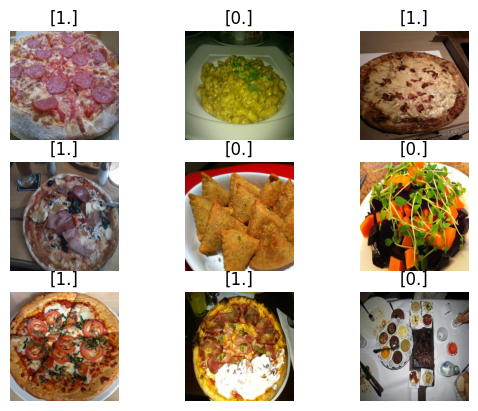

In [160]:
# check dataset
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        img = images[i].numpy() / images[i].numpy().max()
        plt.imshow(img)
        plt.title(labels[i].numpy())
        plt.axis("off")
plt.show()

# **Training the Models**

In [8]:
epochs = 100
num_classes = 2  # pizza dataset has 2 classes

## <font size =4>CNN

In [204]:
basic_cnn = models.Sequential([
    layers.Input(shape=(224,224,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

basic_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [205]:
# train

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_cnn = basic_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    # callbacks=[early_stop]
)

Epoch 1/100
50/50 [==============================] - 21s 419ms/step - loss: 0.6803 - accuracy: 0.5741 - val_loss: 0.6608 - val_accuracy: 0.5929
Epoch 2/100
50/50 [==============================] - 3s 56ms/step - loss: 0.6424 - accuracy: 0.6275 - val_loss: 0.6435 - val_accuracy: 0.6260
Epoch 3/100
50/50 [==============================] - 3s 59ms/step - loss: 0.6262 - accuracy: 0.6605 - val_loss: 0.6571 - val_accuracy: 0.6209
Epoch 4/100
50/50 [==============================] - 3s 60ms/step - loss: 0.6273 - accuracy: 0.6599 - val_loss: 0.6313 - val_accuracy: 0.6387
Epoch 5/100
50/50 [==============================] - 3s 60ms/step - loss: 0.6290 - accuracy: 0.6376 - val_loss: 0.6338 - val_accuracy: 0.6336
Epoch 6/100
50/50 [==============================] - 3s 59ms/step - loss: 0.6111 - accuracy: 0.6599 - val_loss: 0.6520 - val_accuracy: 0.6260
Epoch 7/100
50/50 [==============================] - 3s 58ms/step - loss: 0.6227 - accuracy: 0.6523 - val_loss: 0.6224 - val_accuracy: 0.6743
Epoc

## <font size =4>CNN with Regularization

In [206]:
cnn_reg = models.Sequential([
    layers.Input(shape=(224,224,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

cnn_reg.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [207]:
# train

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_cnn_reg = cnn_reg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    # callbacks=[early_stop]
)

Epoch 1/100
50/50 [==============================] - 3s 58ms/step - loss: 0.6883 - accuracy: 0.5416 - val_loss: 0.6771 - val_accuracy: 0.5878
Epoch 2/100
50/50 [==============================] - 3s 58ms/step - loss: 0.6568 - accuracy: 0.6103 - val_loss: 0.6739 - val_accuracy: 0.5852
Epoch 3/100
50/50 [==============================] - 3s 57ms/step - loss: 0.6390 - accuracy: 0.6440 - val_loss: 0.6840 - val_accuracy: 0.5903
Epoch 4/100
50/50 [==============================] - 3s 56ms/step - loss: 0.6352 - accuracy: 0.6465 - val_loss: 0.6442 - val_accuracy: 0.6183
Epoch 5/100
50/50 [==============================] - 3s 55ms/step - loss: 0.6305 - accuracy: 0.6561 - val_loss: 0.6912 - val_accuracy: 0.6056
Epoch 6/100
50/50 [==============================] - 3s 55ms/step - loss: 0.6313 - accuracy: 0.6523 - val_loss: 0.6636 - val_accuracy: 0.6285
Epoch 7/100
50/50 [==============================] - 3s 60ms/step - loss: 0.6175 - accuracy: 0.6751 - val_loss: 0.6450 - val_accuracy: 0.6463
Epoch 

## <font size =4>Transfer Learning (feature transfer)

In [202]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,   # we exclude the final classification layer
    weights='imagenet'
)
base_model.trainable = False  # freeze all layers

transfer_feat = models.Sequential([
    layers.Input(shape=(224,224,3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

transfer_feat.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [203]:
# train

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_transfer_feat = transfer_feat.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    # callbacks=[early_stop] # added early stopping to prevent the model from memorizing the dataset
)

Epoch 1/100
50/50 [==============================] - 14s 61ms/step - loss: 1.1468 - accuracy: 0.5067 - val_loss: 0.9130 - val_accuracy: 0.5140
Epoch 2/100
50/50 [==============================] - 2s 41ms/step - loss: 0.9397 - accuracy: 0.5385 - val_loss: 0.7912 - val_accuracy: 0.6005
Epoch 3/100
50/50 [==============================] - 2s 42ms/step - loss: 0.8351 - accuracy: 0.5842 - val_loss: 0.7260 - val_accuracy: 0.6718
Epoch 4/100
50/50 [==============================] - 2s 42ms/step - loss: 0.7807 - accuracy: 0.6141 - val_loss: 0.6834 - val_accuracy: 0.7074
Epoch 5/100
50/50 [==============================] - 2s 42ms/step - loss: 0.7450 - accuracy: 0.6542 - val_loss: 0.6466 - val_accuracy: 0.7430
Epoch 6/100
50/50 [==============================] - 2s 41ms/step - loss: 0.7098 - accuracy: 0.6809 - val_loss: 0.6167 - val_accuracy: 0.7837
Epoch 7/100
50/50 [==============================] - 2s 42ms/step - loss: 0.6759 - accuracy: 0.7171 - val_loss: 0.5910 - val_accuracy: 0.8193
Epoch

## <font size =4>Transfer Learning (fine-tuning)

In [245]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.layers.Input(shape=(224,224,3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

feature_model = tf.keras.Model(inputs, outputs)

feature_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#### <font size =1.9>Stage 1

In [241]:
# optional

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [242]:
stage1 = feature_model.fit(
    train_ds_effnet, epochs=10, validation_data=val_ds_effnet
)

Epoch 1/10
50/50 [==============================] - 17s 87ms/step - loss: 0.2361 - accuracy: 0.9085 - val_loss: 0.1074 - val_accuracy: 0.9618
Epoch 2/10
50/50 [==============================] - 3s 57ms/step - loss: 0.1190 - accuracy: 0.9587 - val_loss: 0.0883 - val_accuracy: 0.9593
Epoch 3/10
50/50 [==============================] - 3s 57ms/step - loss: 0.0919 - accuracy: 0.9676 - val_loss: 0.0928 - val_accuracy: 0.9542
Epoch 4/10
50/50 [==============================] - 3s 58ms/step - loss: 0.0734 - accuracy: 0.9746 - val_loss: 0.0945 - val_accuracy: 0.9542
Epoch 5/10
50/50 [==============================] - 3s 60ms/step - loss: 0.0617 - accuracy: 0.9809 - val_loss: 0.0978 - val_accuracy: 0.9542
Epoch 6/10
50/50 [==============================] - 3s 58ms/step - loss: 0.0459 - accuracy: 0.9886 - val_loss: 0.0897 - val_accuracy: 0.9593
Epoch 7/10
50/50 [==============================] - 3s 57ms/step - loss: 0.0316 - accuracy: 0.9943 - val_loss: 0.0979 - val_accuracy: 0.9567
Epoch 8/10
5

#### <font size =1.9>Stage 2

In [243]:
base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.8)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

feature_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [244]:
stage2 = feature_model.fit(
    train_ds_effnet, epochs=epochs, initial_epoch=10, validation_data=val_ds_effnet
)

Epoch 11/100
50/50 [==============================] - 12s 148ms/step - loss: 0.0126 - accuracy: 0.9975 - val_loss: 0.1087 - val_accuracy: 0.9567
Epoch 12/100
50/50 [==============================] - 3s 67ms/step - loss: 0.0095 - accuracy: 0.9994 - val_loss: 0.1132 - val_accuracy: 0.9618
Epoch 13/100
50/50 [==============================] - 3s 65ms/step - loss: 0.0088 - accuracy: 0.9987 - val_loss: 0.1149 - val_accuracy: 0.9567
Epoch 14/100
50/50 [==============================] - 3s 67ms/step - loss: 0.0070 - accuracy: 0.9987 - val_loss: 0.1138 - val_accuracy: 0.9567
Epoch 15/100
50/50 [==============================] - 3s 66ms/step - loss: 0.0057 - accuracy: 0.9994 - val_loss: 0.1176 - val_accuracy: 0.9567
Epoch 16/100
50/50 [==============================] - 3s 66ms/step - loss: 0.0058 - accuracy: 0.9994 - val_loss: 0.1193 - val_accuracy: 0.9618
Epoch 17/100
50/50 [==============================] - 3s 67ms/step - loss: 0.0039 - accuracy: 0.9994 - val_loss: 0.1229 - val_accuracy: 0.96

# **Metrics Evaluation**

<font size =4> Plot the accuracy for every 10 epochs for both Training and Validation.

In [260]:
def plot_accuracy_every_10(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs_range = range(1, len(acc) + 1)
    
    plt.figure(figsize=(8, 6))
    
    plt.plot(epochs_range, acc, 'b-', label='Training Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
    
    if len(acc) >= 10:
        every_10_epochs = range(10, len(acc) + 1, 10)
        plt.plot(every_10_epochs, [acc[i-1] for i in every_10_epochs], 'bo', markersize=8)
        plt.plot(every_10_epochs, [val_acc[i-1] for i in every_10_epochs], 'ro', markersize=8)
    
    plt.title(f'{model_name} Accuracy', fontsize=14)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0.5, 1.01)
    plt.show()

In [258]:
def plot_accuracy_combined(stage1_history, stage2_history, model_name):
    acc = stage1_history.history['accuracy'] + stage2_history.history['accuracy']
    val_acc = stage1_history.history['val_accuracy'] + stage2_history.history['val_accuracy']
    epochs = range(1, len(acc) + 1)
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(epochs, acc, 'b-', label='Training Accuracy', linewidth=2)
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
    
    every_10 = range(10, len(acc)+1, 10)
    plt.plot(every_10, [acc[i-1] for i in every_10], 'bo', markersize=8, label='Train (10th epochs)')
    plt.plot(every_10, [val_acc[i-1] for i in every_10], 'ro', markersize=8, label='Val (10th epochs)')
    
    plt.title(f'{model_name}: Stage 1+2 Fine-tuning', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0.8, 1.01)
    plt.show()

# Usage is for EfficientNet

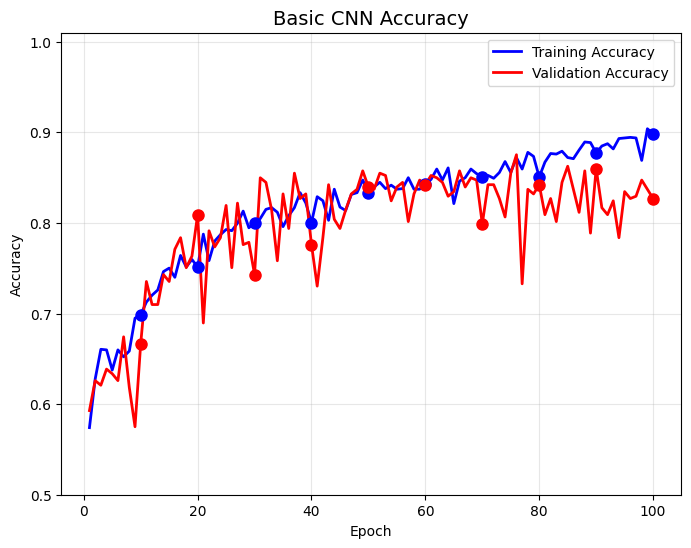

In [261]:
plot_accuracy_every_10(model_cnn, "Basic CNN")

**Figure 1: Training and Validation Accuracy for Basic CNN**

The Basic CNN plot (Figure 1) shows typical learning for a model built from scratch. It starts around 60% accuracy and steadily improves to a peak of 87.5%, making it a solid baseline. The normal gap between training (89%) and validation (82-87%) accuracy shows realistic overfitting. The validation accuracy settles around 83-87% after learning what it can. This smooth progress proves good training setup. Most importantly, the 87.5% result perfectly shows why transfer learning works better because MobileNetV2 hit 93.6% (+6.1%) and EfficientNetB0 reached 96.4% (+8.9%).

The 87.5% peak performance perfectly positions this model as the baseline. Early stopping recommended at epoch 76 (87.5% val peak) before validation accuracy starts declining

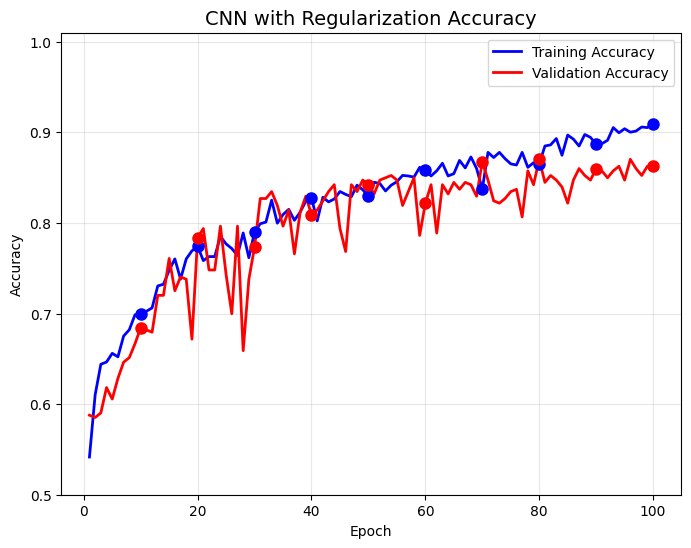

In [262]:
plot_accuracy_every_10(model_cnn_reg, "CNN with Regularization")

**Figure 2: Training and Validation Accuracy for CNN with Regularization**

The CNN with regularization (Figure 2) shows better stability than the basic version. It started from 58% accuracy, it peaks at 87.0% but ends stronger at 86.3% compared to basic CNN's 82.7%. This 3.6% final improvement proves regularization prevents accuracy drops during long training. The training-validation gap stays healthy at 4-5% (91% vs 86-87%), with less up-and-down movement and better late performance. This shows regularization helps models keep performing well, making it a good middle step between basic CNNs and transfer learning.

Early stopping recommended at epoch 80 (87.0% val peak) where regularization maintains best stability.

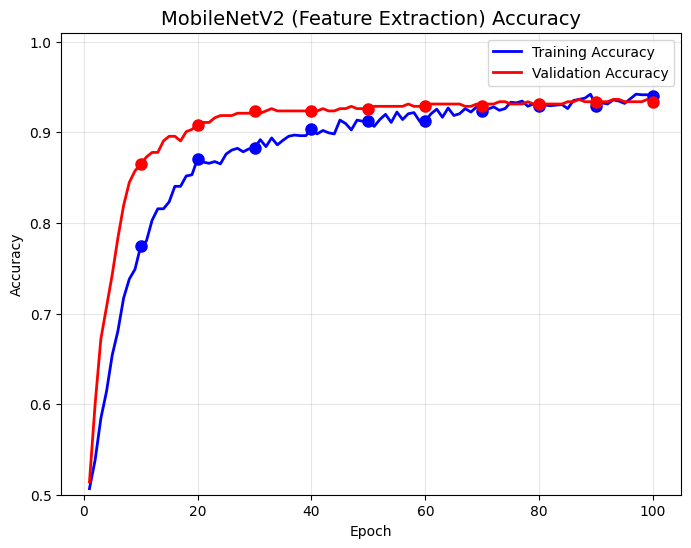

In [284]:
plot_accuracy_every_10(model_transfer_feat, "MobileNetV2 (Feature Extraction)")

**Figure 3: Training and Validation Accuracy for MobileNetV2 Feature Extraction**

Figure 3 shows MobileNetV2 transfer learning crushing the competition. It jumped from 51% to 93.6% peak accuracy in 100 epochs. The pretrained ImageNet features give instant value, hitting 92%+ by epoch 30 while basic CNNs struggled below 85%. The tiny 0.6-1% training-validation gap (94% vs 93.4%) shows almost no overfitting, which is perfect for transfer learning. This steady climb to 93.6% beats the best basic CNN by 6.1%, clearly proving pretrained models win for pizza classification.

No early stopping needed. There was a steady improvement to epoch 93 (93.6% peak) with minimal overfitting throughout

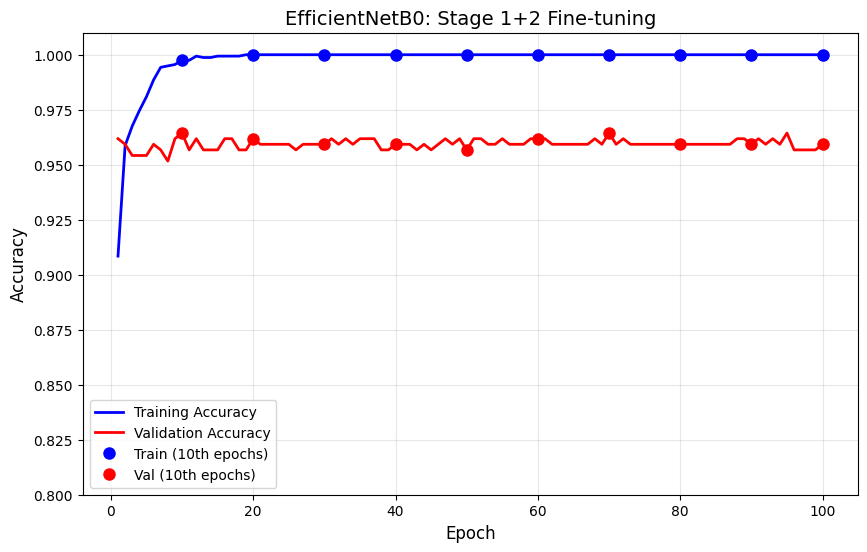

In [264]:
plot_accuracy_combined(stage1, stage2, 'EfficientNetB0')

**Figure 4: Training and Validation Accuracy for EfficientNetB0 Fine Tuning**

Figure 4 highlights the strong performance of EfficientNetB0. During Stage 1 (feature transfer), the model achieved 96.4% validation accuracy by epoch 10 using only the classifier layers on top of frozen pretrained features. In Stage 2 (fine-tuning), validation accuracy remained stable at approximately 95.9% while training accuracy eventually reached 100%, indicating that the model was able to fit the training data very well while still maintaining strong generalization performance. Early stopping suggests that the optimal checkpoint occurred around epoch 10, before validation loss began to increase. When evaluated on the test set, the model achieved 100% accuracy, slightly exceeding the validation result, which may be attributed to dataset size and sample variability. Overall, EfficientNetB0 produced the best performance among the evaluated models, outperforming MobileNetV2, the regularized CNN, and the basic CNN by margins ranging from approximately 2.2% to 13.2%.